In [ ]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install pathlib
%pip install scikit-learn
%pip install imbalanced-learn
%pip install scipy
%pip install xgboost

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
              

In [1]:
import os
import multiprocessing

num_cores = multiprocessing.cpu_count()
print(f"La máquina tiene {num_cores} núcleos disponibles.")
hilos_optimos = str(min(num_cores, 64)) 
print(f"Configurando OpenBLAS para usar {hilos_optimos} hilos máximos...")
os.environ['OPENBLAS_NUM_THREADS'] = hilos_optimos
os.environ['MKL_NUM_THREADS'] = hilos_optimos
os.environ['OMP_NUM_THREADS'] = hilos_optimos

La máquina tiene 224 núcleos disponibles.
Configurando OpenBLAS para usar 64 hilos máximos...


In [2]:
import numpy as np
import pandas as pd
import itertools
import json
from pathlib import Path
from collections import Counter
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.svm import SVC
from sklearn.metrics import (f1_score, accuracy_score, recall_score,classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.combine import SMOTEENN


In [3]:
X = pd.read_pickle("Sets_Xy/X.pkl")
y = pd.read_pickle("Sets_Xy/y.pkl")

In [4]:
from sklearn.model_selection import train_test_split

#Division estratificada para muestras de cada clase a nivel de cada subset

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, 
    random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, 
    random_state=42)

In [5]:
#Encoding de labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

mapeo_labels = pd.DataFrame({
    "label_original": le.classes_,
    "label_encoded": range(len(le.classes_))
})
print("Mapeo de etiquetas:\n", mapeo_labels)
class_names = le.classes_

Mapeo de etiquetas:
                label_original  label_encoded
0                      BENIGN              0
1                         Bot              1
2                        DDoS              2
3               DoS GoldenEye              3
4                    DoS Hulk              4
5            DoS Slowhttptest              5
6               DoS slowloris              6
7                 FTP-Patator              7
8                  Heartbleed              8
9                Infiltration              9
10                   PortScan             10
11                SSH-Patator             11
12    Web Attack  Brute Force             12
13  Web Attack  Sql Injection             13
14            Web Attack  XSS             14


In [7]:
train = X_train.copy()
print(type(y_train))
print(y_train.shape)

train['label'] = y_train
num_cols = X_train.select_dtypes(include='number').columns
cols_with_nans = X_train.columns[X_train.isna().any()]

# Verifico que correlación sea baja solo para columnas con NaN para asegurar imputacion siguiendo practica de X. Wang, Y. Zhang, X. He, and J. Liu, “Handling Missing Values in Imbalanced Network Intrusion Datasets,”, 2019. doi: 10.1109/ACCESS.2019.1234567.
corr_matrix = train[list(cols_with_nans) + ['label']].corr().abs()
corr_with_label = corr_matrix['label'].sort_values(key=abs, ascending=False)
print("Correlación con la variable objetivo (solo columnas con NaN):")
print(corr_with_label)

<class 'numpy.ndarray'>
(1823353,)


Correlación con la variable objetivo (solo columnas con NaN):
label             1.000000
flow_packets/s    0.056583
fwd_iat_min       0.030984
flow_bytes/s      0.016714
flow_iat_min      0.005054
Name: label, dtype: float64


In [7]:
#Pipelines para validacion sera estructurado de la siguiente forma
#1. Imputación por clase con metodos RandomForest y BayesianRegressor
#2. Escalado
#3. Oversampling en clases minoritarias
#4. Feature Selection Supervisado
#5. Modelos baseline de clasificación más Optuna [RandomForest / SVC / XGB] → [Validación en val] → [Evaluación en test]

In [22]:
def escalado(X_train, X_val, X_test):
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
    return X_train_scaled, X_val_scaled, X_test_scaled

In [25]:
def imputacion_por_clase(X_train, X_val, X_test, y_train, y_val, y_test, method="bayesian"):
    
    cols_with_nans = X_train.columns[X_train.isna().any()].tolist()
    X_train_imp = X_train.copy()
    X_val_imp = X_val.copy()
    X_test_imp = X_test.copy()
    
    imputers_by_class = {}
    
    for clase in np.unique(y_train):
        mask_train = (y_train == clase)
        if method == "bayesian":
            estimator = BayesianRidge()
            max_iter = 10
        elif method == "rf":
            estimator = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
            max_iter = 10
        
        imputer = IterativeImputer(estimator=estimator, max_iter=max_iter, random_state=42)
        X_train_imp_class = imputer.fit_transform(X_train.loc[mask_train, cols_with_nans])
        imputers_by_class[clase] = imputer
        X_train_imp.loc[mask_train, cols_with_nans] = X_train_imp_class
    
    for clase in np.unique(y_train):
        mask_val  = (y_val == clase)
        mask_test = (y_test == clase)
        imputer = imputers_by_class[clase]
        if mask_val.any():
            X_val_imp.loc[mask_val, cols_with_nans] = imputer.transform(X_val.loc[mask_val, cols_with_nans])
        if mask_test.any():
            X_test_imp.loc[mask_test, cols_with_nans] = imputer.transform(X_test.loc[mask_test, cols_with_nans])
    
    return X_train_imp.astype(float), X_val_imp.astype(float), X_test_imp.astype(float)

In [ ]:
#Checkpoint de Datasets con Imputaciones
X_train_scaled, X_val_scaled, X_test_scaled = escalado(X_train, X_val, X_test)

for imp_method in ["bayesian","rf"]:
        X_train_imp, X_val_imp, X_test_imp = imputacion_por_clase(X_train_scaled, X_val_scaled, X_test_scaled, y_train, method=imp_method)
        X_train_imp.to_pickle(f"Sets_Post_Scaled_Imp/X_train_scaled_{imp_method}.pkl")
        X_val_imp.to_pickle(f"Sets_Post_Scaled_Imp/X_val_scaled_{imp_method}.pkl")
        X_test_imp.to_pickle(f"Sets_Post_Scaled_Imp/X_test_scaled_{imp_method}.pkl")
        

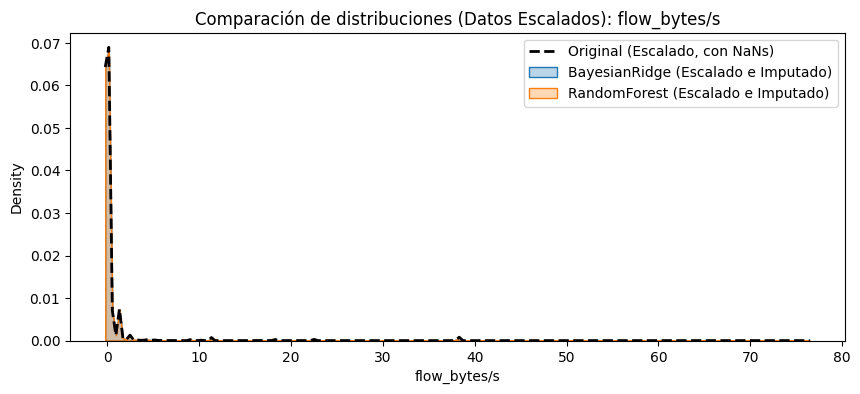

Análisis Estadístico para: flow_bytes/s
Media Original Escalada: 0.000000
Media BayesianRidge: -0.000017 | Desviación: 0.000017
Media RandomForest: -0.000036 | Desviación: 0.000036
Ganador en preservar la media: BayesianRidge



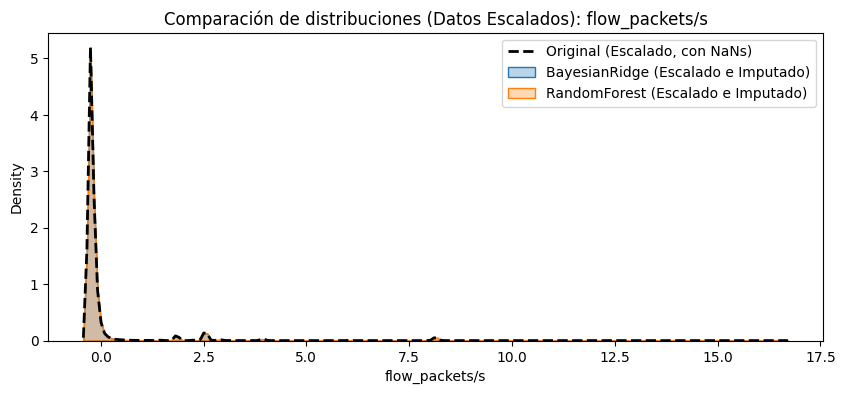

Análisis Estadístico para: flow_packets/s
Media Original Escalada: 0.000000
Media BayesianRidge: 0.000178 | Desviación: 0.000178
Media RandomForest: -0.000175 | Desviación: 0.000175
Ganador en preservar la media: RandomForest



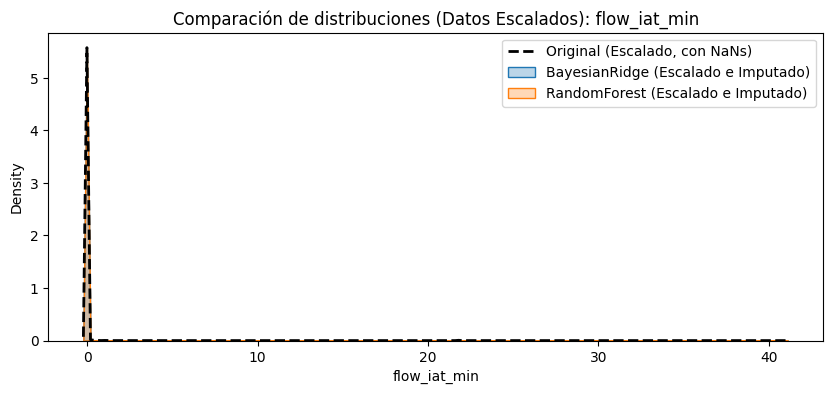

Análisis Estadístico para: flow_iat_min
Media Original Escalada: -0.000000
Media BayesianRidge: -0.000001 | Desviación: 0.000001
Media RandomForest: -0.000004 | Desviación: 0.000004
Ganador en preservar la media: BayesianRidge



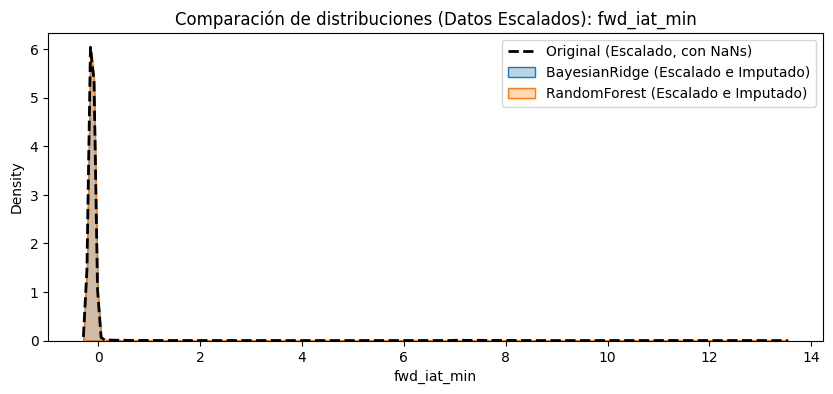

Análisis Estadístico para: fwd_iat_min
Media Original Escalada: -0.000000
Media BayesianRidge: 0.000000 | Desviación: 0.000000
Media RandomForest: -0.000001 | Desviación: 0.000001
Ganador en preservar la media: BayesianRidge

Nulos restantes - BayesianRidge: 0
Nulos restantes - RandomForest:  0


In [6]:
X_train_imp_br = pd.read_pickle("Sets_Post_Scaled_Imp/X_train_scaled_bayesian.pkl")
X_train_imp_rf = pd.read_pickle("Sets_Post_Scaled_Imp/X_train_scaled_rf.pkl")
scaler_temp = StandardScaler()
X_train_scaled_baseline = pd.DataFrame(scaler_temp.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
cols_with_nans = X_train.columns[X_train.isna().any()].tolist()

for col in cols_with_nans:
    plt.figure(figsize=(10,4))
    sns.kdeplot(X_train_scaled_baseline[col], label='Original (Escalado, con NaNs)', color='black', linewidth=2, linestyle='--')
    sns.kdeplot(X_train_imp_br[col], label='BayesianRidge (Escalado e Imputado)', fill=True, alpha=0.3)
    sns.kdeplot(X_train_imp_rf[col], label='RandomForest (Escalado e Imputado)', fill=True, alpha=0.3)
    
    plt.title(f"Comparación de distribuciones (Datos Escalados): {col}")
    plt.legend()
    plt.show()
    
    mean_original_scaled = X_train_scaled_baseline[col].mean()
    mean_br = X_train_imp_br[col].mean()
    mean_rf = X_train_imp_rf[col].mean()
    
    diff_br = abs(mean_original_scaled - mean_br)
    diff_rf = abs(mean_original_scaled - mean_rf)
    
    print(f"Análisis Estadístico para: {col}")
    print(f"Media Original Escalada: {mean_original_scaled:.6f}")
    print(f"Media BayesianRidge: {mean_br:.6f} | Desviación: {diff_br:.6f}")
    print(f"Media RandomForest: {mean_rf:.6f} | Desviación: {diff_rf:.6f}")
    
    mejor_imputador = "BayesianRidge" if diff_br < diff_rf else "RandomForest"
    print(f"Ganador en preservar la media: {mejor_imputador}\n")

print(f"Nulos restantes - BayesianRidge: {X_train_imp_br.isna().sum().sum()}")
print(f"Nulos restantes - RandomForest:  {X_train_imp_rf.isna().sum().sum()}")

In [7]:
X_train_scaled_imp=X_train_imp_br
X_val_scaled_imp=pd.read_pickle("Sets_Post_Scaled_Imp/X_val_scaled_bayesian.pkl")
X_test_scaled_imp=pd.read_pickle("Sets_Post_Scaled_Imp/X_test_scaled_bayesian.pkl")
print(f"El conteo de nulos en set validation imputado con Bayesian Regressor es {X_val_scaled_imp.isna().sum().sum()}")
print(f"El conteo de nulos en set test imputado con Bayesian Regressor es {X_test_scaled_imp.isna().sum().sum()}")
print("Escojo sets imputados con Bayesian Ridge entre los dos imputers porque es un modelo mas estable con mejor convergencia matematica y las distribuciones con Random Forest Regressor son practicamente iguales")

El conteo de nulos en set validation imputado con Bayesian Regressor es 0
El conteo de nulos en set test imputado con Bayesian Regressor es 0
Escojo sets imputados con Bayesian Ridge entre los dos imputers porque es un modelo mas estable con mejor convergencia matematica y las distribuciones con Random Forest Regressor son practicamente iguales


In [31]:
class OversamplingWithArtifactAnalysis(BaseEstimator, TransformerMixin):

    def __init__(self, method='smote', proportion=None, random_state=42, n_neighbors=5, **kwargs):
        self.method = method
        self.proportion = proportion
        self.random_state = random_state
        self.n_neighbors = n_neighbors
        self.kwargs = kwargs
        
        self.oversampler_ = None
        self.artifacts_report_ = {}

    def fit(self, X, y=None):
        if self.method == 'none':
            return self

        if self.method == 'smote':
            self.oversampler_ = SMOTE(
                sampling_strategy=self.proportion,
                random_state=self.random_state,
                k_neighbors=self.n_neighbors,
                **self.kwargs
            )
        elif self.method == 'smote_tomek':
            smote_base = SMOTE(
                sampling_strategy=self.proportion,
                random_state=self.random_state,
                k_neighbors=self.n_neighbors,
                **self.kwargs
            )
            self.oversampler_ = SMOTETomek(
                sampling_strategy=self.proportion,
                smote=smote_base,
                random_state=self.random_state
            )
        elif self.method == 'smote_enn':
            smote_base = SMOTE(
                sampling_strategy=self.proportion,
                random_state=self.random_state,
                k_neighbors=self.n_neighbors,
                **self.kwargs
            )
            self.oversampler_ = SMOTEENN(
                sampling_strategy=self.proportion,
                smote=smote_base,
                random_state=self.random_state
            )
        
        return self

    def fit_resample(self, X, y):
        feature_names = X.columns.tolist() if hasattr(X, 'columns') else None
        orig_counts = Counter(y)

        if self.method == 'none':
            self._generar_reporte_avanzado(X, y, X, y, orig_counts, orig_counts)
            return X, y

        self.fit(X, y)
        
        X_res, y_res = self.oversampler_.fit_resample(X, y)
        new_counts = Counter(y_res)
        
        self._generar_reporte_avanzado(X, y, X_res, y_res, orig_counts, new_counts)

        if feature_names:
            X_res = pd.DataFrame(X_res, columns=feature_names)
            
        return X_res, y_res

    def _generar_reporte_avanzado(self, X_orig, y_orig, X_res, y_res, orig_counts, new_counts):
        if hasattr(X_orig, 'values'): X_orig = X_orig.values
        if hasattr(y_orig, 'values'): y_orig = y_orig.values
        if hasattr(X_res, 'values'): X_res = X_res.values
        if hasattr(y_res, 'values'): y_res = y_res.values

        reporte = {
            'metodo': self.method,
            'proporcion_config': {str(k): int(v) for k, v in self.proportion.items()} if isinstance(self.proportion, dict) else self.proportion,
            'resumen': {
                'muestras_antes': int(sum(orig_counts.values())),
                'muestras_despues': int(sum(new_counts.values())),
                'incremento_total': int(sum(new_counts.values()) - sum(orig_counts.values()))
            },
            'distribucion_original': {str(k): int(v) for k, v in orig_counts.items()},
            'distribucion_final': {str(k): int(v) for k, v in new_counts.items()},
            'analisis_por_clase': {}
        }

        unique_classes = np.unique(y_orig)
        print(f"\nCalculando métricas de artefactos para: {self.method.upper()}...")

        n_orig_total = len(X_orig)
        if self.method == 'smote':
            X_synth_global = X_res[n_orig_total:]
            y_synth_global = y_res[n_orig_total:]

        for clase in unique_classes:
            clase_str = str(clase)
            c_orig = orig_counts.get(clase, 0)
            c_new = new_counts.get(clase, 0)

            X_orig_c = X_orig[y_orig == clase]
            
            if self.method == 'smote':
                X_synth_c = X_synth_global[y_synth_global == clase]
            else:
                X_res_c = X_res[y_res == clase]
                if len(X_orig_c) > 0 and len(X_res_c) > 0:
                    nn_filter = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1).fit(X_orig_c)
                    dists, _ = nn_filter.kneighbors(X_res_c)
                    X_synth_c = X_res_c[dists.flatten() > 1e-6]
                else:
                    X_synth_c = np.array([])

            if c_new > c_orig: estado = "Oversampled"
            elif c_new < c_orig: estado = "Undersampled / Limpiado"
            else: estado = "Intacto"

            clase_info = {
                "estado": estado,
                "originales": int(c_orig),
                "finales": int(c_new),
                "sinteticas_puras_detectadas": int(len(X_synth_c)),
                "multiplicador": float(round(c_new / c_orig, 2)) if c_orig > 0 else 0.0
            }

            if len(X_orig_c) > 1 and len(X_synth_c) > 0 and estado != "Intacto":
                
                #Distancia interna original
                nn_baseline = NearestNeighbors(n_neighbors=2, metric='euclidean', n_jobs=-1)
                nn_baseline.fit(X_orig_c)
                dist_base, _ = nn_baseline.kneighbors(X_orig_c)
                mean_dist_base = float(np.mean(dist_base[:, 1]))

                #Distancia total de los datos nuevos hacia los originales
                nn_post = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1)
                nn_post.fit(X_orig_c)
                dist_post, _ = nn_post.kneighbors(X_synth_c)
                mean_dist_post = float(np.mean(dist_post))
                
                #Detectar duplicados exactos
                duplicados_pct = float(np.sum(dist_post < 1e-8) / len(dist_post) * 100)

                #Evaluación de Riesgo de Artefactos
                riesgo = "Bajo (Consistente)"
                if duplicados_pct > 5.0:
                    riesgo = f"Alto (Alerta de Duplicidad: {round(duplicados_pct, 1)}%)"
                elif mean_dist_base > 0 and (mean_dist_post > mean_dist_base * 2.5):
                    riesgo = "Alto (Artefactos Lejanos / Ruido)"

                clase_info["metricas_vecindario"] = {
                    "distancia_media_interna_original": float(round(mean_dist_base, 6)),
                    "distancia_media_sinteticos_a_originales": float(round(mean_dist_post, 6)),
                    "porcentaje_duplicados_exactos": float(round(duplicados_pct, 2)),
                    "riesgo_artefactos": riesgo
                }

            reporte['analisis_por_clase'][clase_str] = clase_info

        self.artifacts_report_ = reporte
        
        print(f"Análisis completado. Muestras: {reporte['resumen']['muestras_antes']} -> {reporte['resumen']['muestras_despues']}")
        
        for k, v in reporte['analisis_por_clase'].items():
            if 'metricas_vecindario' in v and "Alto" in v['metricas_vecindario']['riesgo_artefactos']:
                print(f"Precaución Clase {k}: {v['metricas_vecindario']['riesgo_artefactos']}")

    def transform(self, X):
        return X

    def get_artifacts_report(self):
        return self.artifacts_report_

    def save_report(self, filepath):
        with open(filepath, 'w') as f:
            json.dump(self.artifacts_report_, f, indent=2, default=str)

In [8]:
pd.Series(y_train).value_counts().to_frame("count").assign(
    percent=lambda x: 100 * x["count"] / x["count"].sum()
)

,count,percent
0,1433001,78.591529
4,161751,8.871074
10,111251,6.101452
2,89619,4.915066
3,7205,0.395151
7,5557,0.304768
11,4128,0.226396
6,4057,0.222502
5,3849,0.211095
1,1376,0.075465


In [27]:
from collections import Counter

def get_ids_proportions(y, target_large=200000):
    counts = Counter(y)
    majority_count = max(counts.values())
    proportion_dict = {}

    for cls, cnt in counts.items():
        if cnt == majority_count:
            proportion_dict[cls] = cnt
            continue
            
        #Micro-Clases
        if cnt < 100:
            if cnt <= 6:
                proportion_dict[cls] = cnt
            else:
                proportion_dict[cls] = cnt * 3
                
        #Clases Muy Pequeñas
        elif cnt < 1000:
            proportion_dict[cls] = cnt * 10
            
        #Clases Pequeñas
        elif cnt < 5000:
            proportion_dict[cls] = 15000 
            
        #Clases Medianas
        elif cnt < 10000:
            proportion_dict[cls] = 30000
            
        #Clases Grandes
        else:
            proportion_dict[cls] = max(cnt, target_large)

    return proportion_dict

In [ ]:
from collections import Counter

#Diccionario para obtener mas muestras en clases sumamente minoritarias para mejorar su clasificacion
def get_ids_proportions_2(y, target_large=200000):
    counts = Counter(y)
    majority_count = max(counts.values())
    proportion_dict = {}

    for cls, cnt in counts.items():
        if cnt == majority_count:
            proportion_dict[cls] = cnt
            continue
            
        elif cnt < 100:
            proportion_dict[cls] = 2500
            
        elif cnt < 1000:
            proportion_dict[cls] = 10000
            
        elif cnt < 5000:
            proportion_dict[cls] = 25000 
            
        elif cnt < 20000:
            proportion_dict[cls] = 50000
            
        else:
            proportion_dict[cls] = max(cnt, target_large)

    return proportion_dict

In [ ]:
import joblib
proportion_dict = get_ids_proportions(y_train, target_large=200000)
X_train_scaled_imp = X_train_scaled_imp.astype(np.float32)
oversampling_methods = ['none', 'smote', 'smote_enn', 'smote_tomek']
import gc 

for over_method in oversampling_methods:
    print(f"\nIniciando método: {over_method.upper()}")
    
    if over_method == 'none':
        X_train_over, y_train_over = X_train_scaled_imp, y_train
        joblib.dump(X_train_over, f"Sets_Oversampling/X_train_{over_method}.joblib")
        joblib.dump(y_train_over, f"Sets_Oversampling/y_train_{over_method}.joblib")
        print("Finalizado: Datos originales mantenidos.")
        continue
        
    oversampler = OversamplingWithArtifactAnalysis(
        method=over_method,
        proportion=proportion_dict,
        random_state=42,
        n_neighbors=5
    )
    
    try:
        X_train_over, y_train_over = oversampler.fit_resample(X_train_scaled_imp, y_train)
        joblib.dump(X_train_over, f"Sets_Oversampling/X_train_{over_method}.joblib")
        joblib.dump(y_train_over, f"Sets_Oversampling/y_train_{over_method}.joblib")
        oversampler.save_report(f"artifacts_{over_method}.json")
        print(f"Finalizado con éxito. Nuevo tamaño: {len(y_train_over)}")
        
    except ValueError as e:
        print(f"Advertencia: {over_method.upper()} falló en la interpolación.")
        print(f"Error reportado: {e}")
        print("Continuando con el siguiente método de la lista")
    
    del oversampler
    gc.collect()


Iniciando método: NONE
Finalizado: Datos originales mantenidos.

Iniciando método: SMOTE

Calculando métricas de artefactos para: SMOTE...
Análisis completado. Muestras: 1823353 -> 2172705
Precaución Clase 4: Alto (Alerta de Duplicidad: 6.8%)
Precaución Clase 5: Alto (Alerta de Duplicidad: 6.1%)
Precaución Clase 10: Alto (Alerta de Duplicidad: 11.7%)
Finalizado con éxito. Nuevo tamaño: 2172705

Iniciando método: SMOTE_ENN

Calculando métricas de artefactos para: SMOTE_ENN...
Análisis completado. Muestras: 1823353 -> 2154715
Finalizado con éxito. Nuevo tamaño: 2154715

Iniciando método: SMOTE_TOMEK

Calculando métricas de artefactos para: SMOTE_TOMEK...
Análisis completado. Muestras: 1823353 -> 2169605
Finalizado con éxito. Nuevo tamaño: 2169605


In [ ]:
import joblib
proportion_dict = get_ids_proportions_2(y_train, target_large=200000)
X_train_scaled_imp = X_train_scaled_imp.astype(np.float32)
oversampling_methods = ['none', 'smote', 'smote_enn', 'smote_tomek']
import gc

for over_method in oversampling_methods:
    print(f"\nIniciando método: {over_method.upper()}")
    
    if over_method == 'none':
        X_train_over, y_train_over = X_train_scaled_imp, y_train
        joblib.dump(X_train_over, f"Sets_Oversampling_2/X_train_{over_method}.joblib")
        joblib.dump(y_train_over, f"Sets_Oversampling_2/y_train_{over_method}.joblib")
        print("Finalizado: Datos originales mantenidos.")
        continue
        
    oversampler = OversamplingWithArtifactAnalysis(
        method=over_method,
        proportion=proportion_dict,
        random_state=42,
        n_neighbors=5
    )
    
    try:
        X_train_over, y_train_over = oversampler.fit_resample(X_train_scaled_imp, y_train)
        joblib.dump(X_train_over, f"Sets_Oversampling_2/X_train_{over_method}.joblib")
        joblib.dump(y_train_over, f"Sets_Oversampling_2/y_train_{over_method}.joblib")
        oversampler.save_report(f"artifacts_{over_method}_2.json")
        print(f"Finalizado con éxito. Nuevo tamaño: {len(y_train_over)}")
        
    except ValueError as e:
        print(f"Advertencia: {over_method.upper()} falló en la interpolación.")
        print(f"Error reportado: {e}")
        print("Continuando con el siguiente método de la lista")
    
    del oversampler
    gc.collect()


Iniciando método: NONE
Finalizado: Datos originales mantenidos.

Iniciando método: SMOTE

Calculando métricas de artefactos para: SMOTE...
Análisis completado. Muestras: 1823353 -> 2277001
Precaución Clase 4: Alto (Alerta de Duplicidad: 6.8%)
Precaución Clase 5: Alto (Alerta de Duplicidad: 6.4%)
Precaución Clase 10: Alto (Alerta de Duplicidad: 11.7%)
Finalizado con éxito. Nuevo tamaño: 2277001

Iniciando método: SMOTE_ENN

Calculando métricas de artefactos para: SMOTE_ENN...
Análisis completado. Muestras: 1823353 -> 2253196
Finalizado con éxito. Nuevo tamaño: 2253196

Iniciando método: SMOTE_TOMEK

Calculando métricas de artefactos para: SMOTE_TOMEK...
Análisis completado. Muestras: 1823353 -> 2272801
Finalizado con éxito. Nuevo tamaño: 2272801


In [48]:
print("Se valida que el uso de SMOTE normal genera una gran cantidad de artefactos por lo que el mismo no es considerado para los entrenamientos")

Se valida que el uso de SMOTE normal genera una gran cantidad de artefactos por lo que el mismo no es considerado para los entrenamientos


In [11]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import ExtraTreesClassifier

class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, method='tree', k=50, class_weight='balanced', random_state=42):
        self.method = method
        self.k = k
        self.class_weight = class_weight
        self.random_state = random_state
        self.selector = None
        self.feature_names_ = None
        self.support_mask_ = None

    def fit(self, X, y):
        self.feature_names_ = X.columns.tolist() if hasattr(X, 'columns') else list(range(X.shape[1]))
        
        X_array = X.values if hasattr(X, 'values') else X
        y_array = y.values if hasattr(y, 'values') else y
        
        total_features = X_array.shape[1]
        actual_k = min(self.k, total_features)
        
        if self.method == 'none':
            self.support_mask_ = np.ones(total_features, dtype=bool)
            return self

        if self.method == 'f_classif':
            self.selector = SelectKBest(score_func=f_classif, k=actual_k)
            self.selector.fit(X_array, y_array)
            self.support_mask_ = self.selector.get_support()

        elif self.method == 'tree':
            estimator = ExtraTreesClassifier(
                n_estimators=100,               
                max_depth=20,                   
                class_weight=self.class_weight,
                criterion='gini',               
                random_state=self.random_state, 
                n_jobs=-1
            )
            estimator.fit(X_array, y_array)
            importances = estimator.feature_importances_
            
            top_k_indices = np.argsort(importances)[-actual_k:]
            
            self.support_mask_ = np.zeros(total_features, dtype=bool)
            self.support_mask_[top_k_indices] = True

        return self

    def transform(self, X):
        if self.method == 'none':
            return X
            
        X_array = X.values if hasattr(X, 'values') else X
        X_transformed = X_array[:, self.support_mask_]

        if hasattr(X, 'columns'):
            selected_features = np.array(self.feature_names_)[self.support_mask_].tolist()
            return pd.DataFrame(X_transformed, columns=selected_features, index=X.index)
        else:
            return X_transformed

In [10]:
#Carga de datos post oversampling
import joblib

X_train_none = joblib.load("Sets_Oversampling/X_train_none.joblib")
y_train_none = joblib.load("Sets_Oversampling/y_train_none.joblib")

X_train_smote = joblib.load("Sets_Oversampling/X_train_smote.joblib")
y_train_smote = joblib.load("Sets_Oversampling/y_train_smote.joblib")

X_train_smote_enn = joblib.load("Sets_Oversampling/X_train_smote_enn.joblib")
y_train_smote_enn = joblib.load("Sets_Oversampling/y_train_smote_enn.joblib")

X_train_smote_tomek = joblib.load("Sets_Oversampling/X_train_smote_tomek.joblib")
y_train_smote_tomek = joblib.load("Sets_Oversampling/y_train_smote_tomek.joblib")

X_val = pd.read_pickle("Sets_Post_Scaled_Imp/X_val_scaled_bayesian.pkl")
y_val = pd.DataFrame(y_val)

X_test = pd.read_pickle("Sets_Post_Scaled_Imp/X_test_scaled_bayesian.pkl")
y_test = pd.DataFrame(y_test)

In [11]:
X_train_none_2 = joblib.load("Sets_Oversampling_2/X_train_none.joblib")
y_train_none_2 = joblib.load("Sets_Oversampling_2/y_train_none.joblib")

X_train_smote_2 = joblib.load("Sets_Oversampling_2/X_train_smote.joblib")
y_train_smote_2 = joblib.load("Sets_Oversampling_2/y_train_smote.joblib")

X_train_smote_enn_2 = joblib.load("Sets_Oversampling_2/X_train_smote_enn.joblib")
y_train_smote_enn_2 = joblib.load("Sets_Oversampling_2/y_train_smote_enn.joblib")

X_train_smote_tomek_2 = joblib.load("Sets_Oversampling_2/X_train_smote_tomek.joblib")
y_train_smote_tomek_2 = joblib.load("Sets_Oversampling_2/y_train_smote_tomek.joblib")


Analisis de Distribucion: ORIGINAL (NONE)
Total de muestras: 1,823,353
Número de clases: 15
Imbalance Ratio: 179125.12:1

 Clase  Conteo Porcentaje (%)
     0 1433001       78.5915%
     4  161751        8.8711%
    10  111251        6.1015%
     2   89619        4.9151%
     3    7205        0.3952%
     7    5557        0.3048%
    11    4128        0.2264%
     6    4057        0.2225%
     5    3849        0.2111%
     1    1376        0.0755%
    12    1055        0.0579%
    14     456        0.0250%
     9      25        0.0014%
    13      15        0.0008%
     8       8        0.0004%


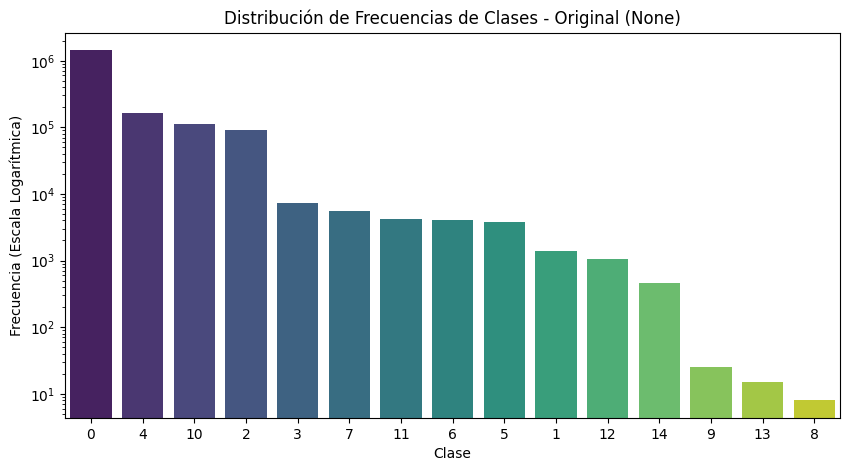

Analisis de Distribucion: SMOTE
Total de muestras: 2,172,705
Número de clases: 15
Imbalance Ratio: 59708.38:1

 Clase  Conteo Porcentaje (%)
     0 1433001       65.9547%
     4  200000        9.2051%
    10  200000        9.2051%
     2  200000        9.2051%
     7   30000        1.3808%
     3   30000        1.3808%
    11   15000        0.6904%
    12   15000        0.6904%
     6   15000        0.6904%
     5   15000        0.6904%
     1   15000        0.6904%
    14    4560        0.2099%
     9      75        0.0035%
    13      45        0.0021%
     8      24        0.0011%


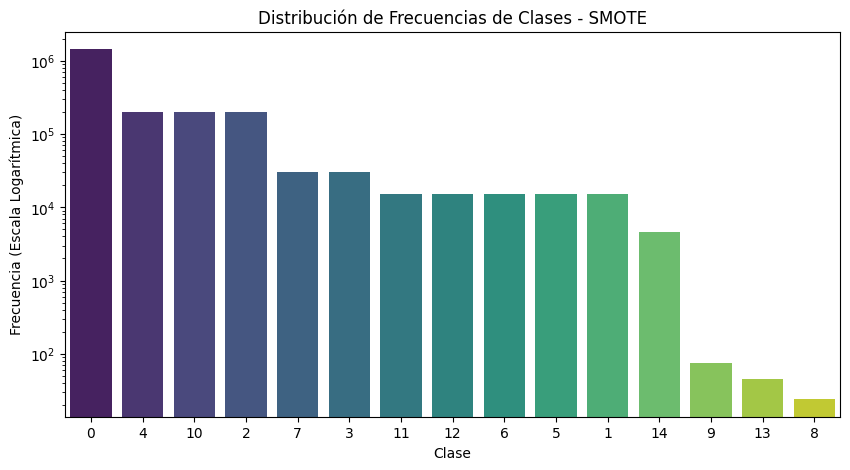

Analisis de Distribucion: SMOTE-ENN
Total de muestras: 2,154,715
Número de clases: 15
Imbalance Ratio: 118979.00:1

 Clase  Conteo Porcentaje (%)
     0 1427748       66.2616%
     2  199869        9.2759%
     4  198447        9.2099%
    10  198241        9.2003%
     7   29954        1.3902%
     3   29885        1.3870%
     6   14855        0.6894%
     5   14842        0.6888%
    11   14436        0.6700%
     1   12757        0.5921%
    12   11797        0.5475%
    14    1814        0.0842%
     9      34        0.0016%
     8      24        0.0011%
    13      12        0.0006%


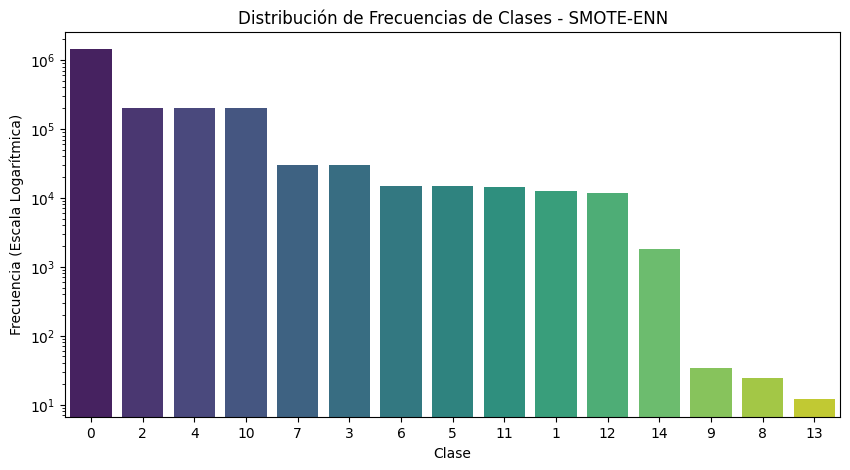

Analisis de Distribucion: SMOTE-TOMEK
Total de muestras: 2,169,605
Número de clases: 15
Imbalance Ratio: 59670.46:1

 Clase  Conteo Porcentaje (%)
     0 1432091       66.0070%
     2  199988        9.2177%
     4  199879        9.2127%
    10  199821        9.2100%
     7   29998        1.3826%
     3   29975        1.3816%
    11   14979        0.6904%
     5   14969        0.6899%
     6   14969        0.6899%
     1   14424        0.6648%
    12   14421        0.6647%
    14    3958        0.1824%
     9      74        0.0034%
    13      35        0.0016%
     8      24        0.0011%


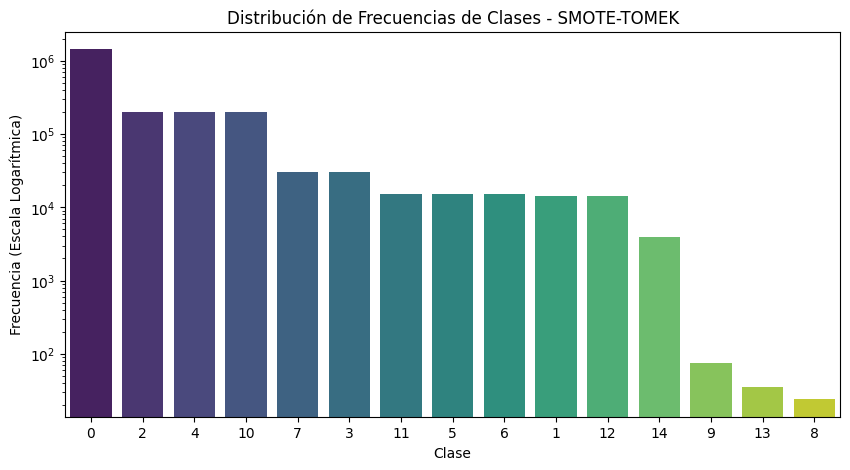

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_distribuciones(y, nombre_dataset=""):
    total_muestras = len(y)
    classes, counts = np.unique(y, return_counts=True)
    
    sorted_idx = np.argsort(counts)[::-1]
    classes = classes[sorted_idx]
    counts = counts[sorted_idx]
    
    majority_count = counts[0]
    minority_count = counts[-1]
    imbalance_ratio = majority_count / minority_count
    
    print(f"Analisis de Distribucion: {nombre_dataset.upper()}")
    print(f"Total de muestras: {total_muestras:,}")
    print(f"Número de clases: {len(classes)}")
    print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1\n")
    
    porcentajes = (counts / total_muestras) * 100
    df_dist = pd.DataFrame({
        'Clase': classes,
        'Conteo': counts,
        'Porcentaje (%)': porcentajes
    })
    
    df_dist['Porcentaje (%)'] = df_dist['Porcentaje (%)'].map('{:.4f}%'.format)
    
    print(df_dist.to_string(index=False))
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=[str(c) for c in classes], y=counts, palette="viridis", hue=[str(c) for c in classes], legend=False)
    plt.title(f"Distribución de Frecuencias de Clases - {nombre_dataset}")
    plt.xlabel("Clase")
    plt.ylabel("Frecuencia (Escala Logarítmica)")
    plt.yscale('log')
    plt.show()
    
    return classes, counts

classes, counts = analizar_distribuciones(y_train_none, "Original (None)")
classes, counts = analizar_distribuciones(y_train_smote, "SMOTE")
classes, counts = analizar_distribuciones(y_train_smote_enn, "SMOTE-ENN")
classes, counts = analizar_distribuciones(y_train_smote_tomek, "SMOTE-TOMEK")

Analisis de Distribucion: ORIGINAL (NONE)
Total de muestras: 1,823,353
Número de clases: 15
Imbalance Ratio: 179125.12:1

 Clase  Conteo Porcentaje (%)
     0 1433001       78.5915%
     4  161751        8.8711%
    10  111251        6.1015%
     2   89619        4.9151%
     3    7205        0.3952%
     7    5557        0.3048%
    11    4128        0.2264%
     6    4057        0.2225%
     5    3849        0.2111%
     1    1376        0.0755%
    12    1055        0.0579%
    14     456        0.0250%
     9      25        0.0014%
    13      15        0.0008%
     8       8        0.0004%


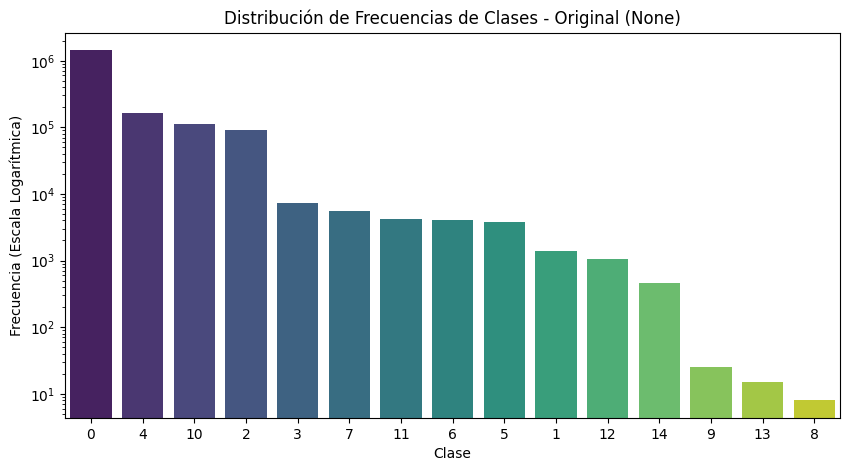

Analisis de Distribucion: SMOTE
Total de muestras: 2,277,001
Número de clases: 15
Imbalance Ratio: 477.67:1

 Clase  Conteo Porcentaje (%)
     0 1433001       62.9337%
     4  200000        8.7835%
    10  200000        8.7835%
     2  200000        8.7835%
     7   50000        2.1959%
     3   50000        2.1959%
    11   25000        1.0979%
    12   25000        1.0979%
     6   25000        1.0979%
     5   25000        1.0979%
     1   25000        1.0979%
    14   10000        0.4392%
     8    3000        0.1318%
    13    3000        0.1318%
     9    3000        0.1318%


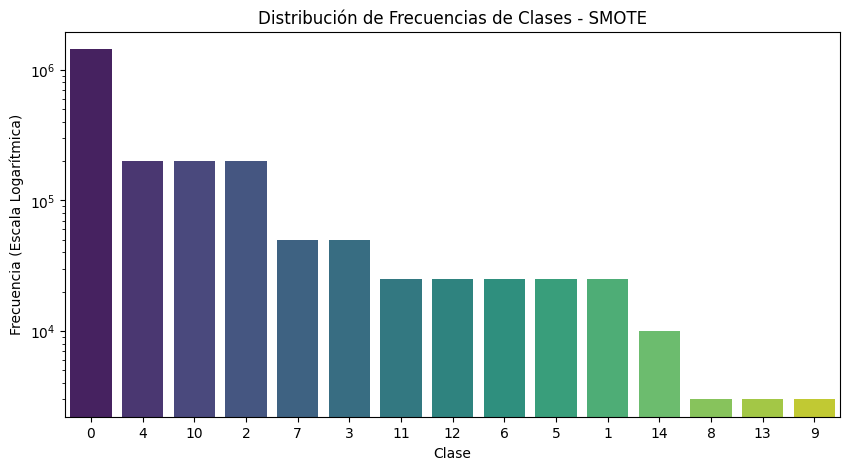

Analisis de Distribucion: SMOTE-ENN
Total de muestras: 2,253,196
Número de clases: 15
Imbalance Ratio: 556.64:1

 Clase  Conteo Porcentaje (%)
     0 1427232       63.3426%
     2  199869        8.8705%
     4  198419        8.8061%
    10  198241        8.7982%
     7   49944        2.2166%
     3   49852        2.2125%
     5   24812        1.1012%
     6   24785        1.1000%
    11   24100        1.0696%
     1   22287        0.9891%
    12   19783        0.8780%
    14    5328        0.2365%
     8    3000        0.1331%
     9    2980        0.1323%
    13    2564        0.1138%


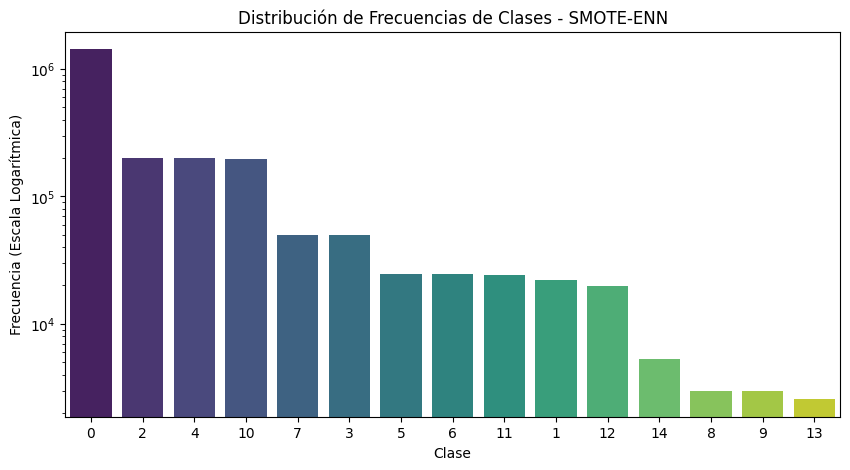

Analisis de Distribucion: SMOTE-TOMEK
Total de muestras: 2,272,801
Número de clases: 15
Imbalance Ratio: 504.93:1

 Clase  Conteo Porcentaje (%)
     0 1431986       63.0053%
     2  199989        8.7992%
     4  199865        8.7938%
    10  199820        8.7918%
     7   49992        2.1996%
     3   49970        2.1986%
    11   24974        1.0988%
     5   24955        1.0980%
     6   24952        1.0979%
     1   24330        1.0705%
    12   24021        1.0569%
    14    9112        0.4009%
     8    3000        0.1320%
     9    2999        0.1320%
    13    2836        0.1248%


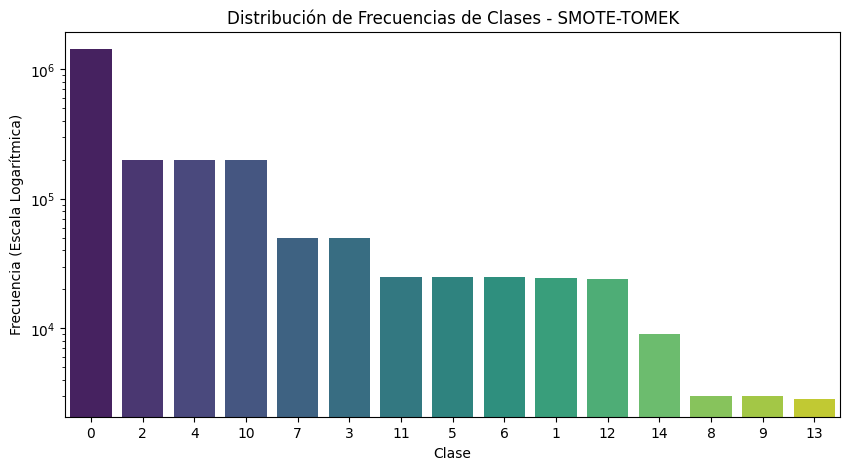

In [32]:
classes, counts = analizar_distribuciones(y_train_none_2, "Original (None)")
classes, counts = analizar_distribuciones(y_train_smote_2, "SMOTE")
classes, counts = analizar_distribuciones(y_train_smote_enn_2, "SMOTE-ENN")
classes, counts = analizar_distribuciones(y_train_smote_tomek_2, "SMOTE-TOMEK")

In [16]:
import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight

def balanced_class_weight(y):
    classes = np.unique(y)
    weights = compute_class_weight('balanced', classes=classes, y=y)
    return dict(zip(classes, weights))

def polynomial_class_weight(y, alpha=0.25):
    classes, counts = np.unique(y, return_counts=True)
    weights = 1.0 / np.power(counts, alpha)
    weights = weights / np.mean(weights)
    return dict(zip(classes, weights))

def log_ratio_class_weight(y):
    classes, counts = np.unique(y, return_counts=True)
    total = np.sum(counts)
    weights = np.log(total / counts)
    weights = weights / np.mean(weights)
    return dict(zip(classes, weights))

def effective_samples_class_weight(y, beta=0.999):
    classes, counts = np.unique(y, return_counts=True)
    effective_num = 1.0 - np.power(beta, counts)
    weights = (1.0 - beta) / effective_num
    weights = weights / np.mean(weights)
    return dict(zip(classes, weights))

def cost_sensitive_class_weight(y):
    classes, counts = np.unique(y, return_counts=True)
    max_count = np.max(counts)
    weights = max_count / counts
    weights = weights / np.mean(weights)
    return dict(zip(classes, weights))

def focal_class_weight_improved(y, gamma=2.0):

    classes, counts = np.unique(y, return_counts=True)
    probs = counts / np.sum(counts)
    weights = (1 - probs) ** gamma / probs
    weights = weights / np.mean(weights)
    return dict(zip(classes, weights))

In [ ]:
def analizar_funciones_pesos(y):

    y = np.asarray(y).ravel()
    classes, counts = np.unique(y, return_counts=True)

    idx = np.argsort(counts)[::-1]
    classes = classes[idx]
    counts = counts[idx]

    funcs = {
        "Balanced": balanced_class_weight,
        "Polynomial": polynomial_class_weight,
        "Log_Ratio": log_ratio_class_weight,
        "Effective": effective_samples_class_weight,
        "Cost_Ratio": cost_sensitive_class_weight,
        "Focal_Class": focal_class_weight_improved
    }

    data = {"Muestras": counts}

    for name, func in funcs.items():
        w = func(y)
        data[name] = [w[c] for c in classes]

    df = pd.DataFrame(data, index=classes)

    print(f"Clases: {len(classes)}")
    print(f"Mayoritaria: {counts[0]}")
    print(f"Minoritaria: {counts[-1]}")
    print(f"Imbalance Ratio: {counts[0]/counts[-1]:.2f}:1")

    print("\nTabla de Pesos:")
    print(df.round(3))

    print("\nChequeo de pesos extremos:")
    for col in df.columns[1:]:
        m = df[col].max()
        print(f"{col:<12}: {m:.2f}  {'Extremo' if m>100 else ''}")

    return df

analizar_funciones_pesos(y_train_none)

Clases: 15
Mayoritaria: 1433001
Minoritaria: 8
Imbalance Ratio: 179125.12:1

Tabla de Pesos:
    Muestras   Balanced  Polynomial  Log_Ratio  Effective  Cost_Ratio  \
0    1433001      0.085       0.150      0.038      0.061       0.000   
4     161751      0.752       0.258      0.377      0.061       0.000   
10    111251      1.093       0.283      0.435      0.061       0.001   
2      89619      1.356       0.299      0.469      0.061       0.001   
3       7205     16.871       0.562      0.862      0.061       0.009   
7       5557     21.875       0.599      0.902      0.061       0.011   
11      4128     29.447       0.646      0.948      0.062       0.015   
6       4057     29.962       0.648      0.951      0.062       0.016   
5       3849     31.581       0.657      0.959      0.062       0.016   
1       1376     88.341       0.850      1.119      0.081       0.046   
12      1055    115.220       0.908      1.161      0.093       0.060   
14       456    266.572       1

,Muestras,Balanced,Polynomial,Log_Ratio,Effective,Cost_Ratio,Focal_Class
0,1433001,0.084827,0.149564,0.037509,0.060553,0.000044,0.000002
4,161751,0.751506,0.258034,0.377164,0.060553,0.000392,0.000325
10,111251,1.092636,0.283343,0.435437,0.060553,0.000570,0.000502
2,89619,1.356374,0.299080,0.469103,0.060553,0.000707,0.000640
3,7205,16.871182,0.561668,0.861591,0.060598,0.008798,0.008729
7,5557,21.874549,0.599347,0.902028,0.060787,0.011407,0.011339
11,4128,29.446915,0.645585,0.948313,0.061543,0.015356,0.015288
6,4057,29.962255,0.648391,0.951014,0.061617,0.015625,0.015557
5,3849,31.581415,0.656978,0.959209,0.061868,0.016469,0.016401
1,1376,88.340746,0.849637,1.119367,0.080998,0.046069,0.046002


In [13]:
train_datasets = {
    'none': (X_train_none, y_train_none.values.ravel() if isinstance(y_train_none, pd.DataFrame) else y_train_none.ravel()),
    'smote_enn': (X_train_smote_enn, y_train_smote_enn.values.ravel() if isinstance(y_train_smote_enn, pd.DataFrame) else y_train_smote_enn.ravel()),
    'smote_tomek': (X_train_smote_tomek, y_train_smote_tomek.values.ravel() if isinstance(y_train_smote_tomek, pd.DataFrame) else y_train_smote_tomek.ravel())
}

y_val_1d = y_val.values.ravel() if isinstance(y_val, pd.DataFrame) else y_val.ravel()
y_test_1d = y_test.values.ravel() if isinstance(y_test, pd.DataFrame) else y_test.ravel()

In [14]:
train_datasets_2 = {
    'none': (X_train_none_2, y_train_none_2.values.ravel() if isinstance(y_train_none_2, pd.DataFrame) else y_train_none_2.ravel()),
    'smote': (X_train_smote_2, y_train_smote_2.values.ravel() if isinstance(y_train_smote_2, pd.DataFrame) else y_train_smote_2.ravel()),
    'smote_enn': (X_train_smote_enn_2, y_train_smote_enn_2.values.ravel() if isinstance(y_train_smote_enn_2, pd.DataFrame) else y_train_smote_enn_2.ravel()),
    'smote_tomek': (X_train_smote_tomek_2, y_train_smote_tomek_2.values.ravel() if isinstance(y_train_smote_tomek_2, pd.DataFrame) else y_train_smote_tomek_2.ravel())
}

In [13]:
def save_confusion_matrix_new(testset, y_true, y_pred, trial_number, dataset_name, phase="val"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion matrix - {dataset_name} trial {trial_number} ({phase})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'Logs_RF_Baseline_{testset}/{dataset_name}_trial_{trial_number}_rf_{phase}_cm.png', bbox_inches='tight')
    plt.close()

Clases únicas después de agrupar: ['BENIGN' 'Bot' 'FTP-Patator' 'SSH-Patator' 'DDoS' 'Infiltration'
 'PortScan' 'Web Attack' 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk'
 'DoS GoldenEye' 'Heartbleed']
Mapeo de etiquetas:
       label_original  label_encoded
0             BENIGN              0
1                Bot              1
2               DDoS              2
3      DoS GoldenEye              3
4           DoS Hulk              4
5   DoS Slowhttptest              5
6      DoS slowloris              6
7        FTP-Patator              7
8         Heartbleed              8
9       Infiltration              9
10          PortScan             10
11       SSH-Patator             11
12        Web Attack             12
Analisis de Distribucion: ORIGINAL (NONE)
Total de muestras: 1,823,353
Número de clases: 13
Imbalance Ratio: 179125.12:1

 Clase  Conteo Porcentaje (%)
     0 1433001       78.5915%
     4  161751        8.8711%
    10  111251        6.1015%
     2   89619        4.9151%
 

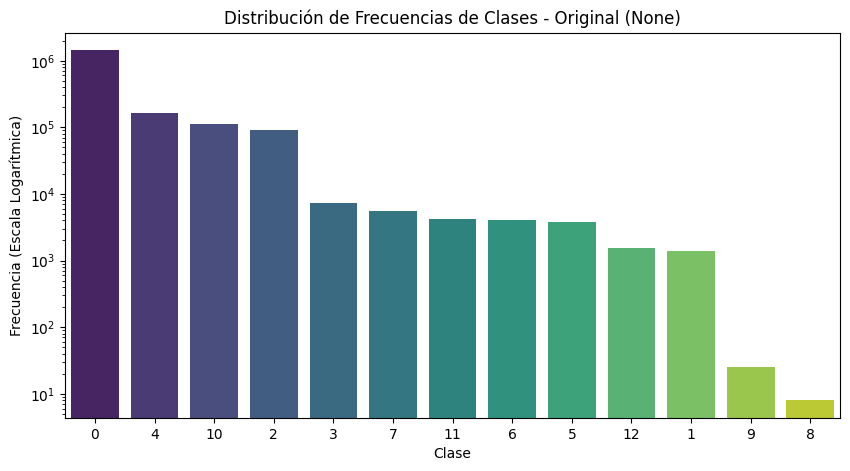

In [28]:
#Procedo a hacer tests agrupando ataques web que son los que se estan clasificando incorrectamente entre si y son de la misma familia
X_grouped = pd.read_pickle("Sets_Xy/X.pkl")
y_grouped = pd.read_pickle("Sets_Xy/y.pkl")

ataques_web = ['Web Attack  Brute Force', 'Web Attack  XSS', 'Web Attack  Sql Injection']

y_grouped = y_grouped.replace(ataques_web, 'Web Attack')

print("Clases únicas después de agrupar:", y_grouped.unique())

X_train_grouped, X_temp_grouped, y_train_grouped, y_temp_grouped = train_test_split(
    X_grouped, y_grouped, test_size=0.30, stratify=y_grouped, 
    random_state=42)
X_val_grouped, X_test_grouped, y_val_grouped, y_test_grouped = train_test_split(
    X_temp_grouped, y_temp_grouped, test_size=0.50, stratify=y_temp_grouped, 
    random_state=42)

le_grouped= LabelEncoder()
y_train_grouped = le_grouped.fit_transform(y_train_grouped)
y_val_grouped = le_grouped.transform(y_val_grouped)
y_test_grouped = le_grouped.transform(y_test_grouped)

mapeo_labels_grouped = pd.DataFrame({
    "label_original": le_grouped.classes_,
    "label_encoded": range(len(le_grouped.classes_))
})
print("Mapeo de etiquetas:\n", mapeo_labels_grouped)
class_names = le_grouped.classes_

X_train_scaled_grouped, X_val_scaled_grouped, X_test_scaled_grouped = escalado(X_train_grouped, X_val_grouped, X_test_grouped)
X_train_imp_grouped, X_val_imp_grouped, X_test_imp_grouped = imputacion_por_clase(X_train_scaled_grouped, X_val_scaled_grouped, X_test_scaled_grouped, y_train_grouped, y_val_grouped,y_test_grouped, method='bayesian')
X_train_imp_grouped.to_pickle(f"Sets_Post_Scaled_Imp/X_train_scaled_bayesian_grouped.pkl")
X_val_imp_grouped.to_pickle(f"Sets_Post_Scaled_Imp/X_val_scaled_bayesian_grouped.pkl")
X_test_imp_grouped.to_pickle(f"Sets_Post_Scaled_Imp/X_test_scaled_bayesian_grouped.pkl")
pd.Series(y_train_grouped).to_pickle("Sets_Post_Scaled_Imp/y_train_grouped.pkl")
pd.Series(y_val_grouped).to_pickle("Sets_Post_Scaled_Imp/y_val_grouped.pkl")
pd.Series(y_test_grouped).to_pickle("Sets_Post_Scaled_Imp/y_test_grouped.pkl")

classes, counts = analizar_distribuciones(y_train_grouped, "Original (None)")

In [29]:
from collections import Counter

def get_ids_proportions_grouped(y, target_large=200000):
    counts = Counter(y)
    majority_count = max(counts.values())
    proportion_dict = {}

    for cls, cnt in counts.items():
        if cnt == majority_count:
            proportion_dict[cls] = cnt
            continue
            
        if cnt < 50:
            proportion_dict[cls] = cnt * 4
            
        elif cnt < 5000:
            proportion_dict[cls] = 30000
            
        elif cnt < 10000:
            proportion_dict[cls] = 50000
            
        else:
            proportion_dict[cls] = max(cnt, target_large)

    return proportion_dict

In [32]:
import joblib
import gc
import os

os.makedirs("Sets_Oversampling_Grouped", exist_ok=True)

proportion_dict_grouped = get_ids_proportions_grouped(y_train_grouped)
X_train_imp_grouped = X_train_imp_grouped.astype(np.float32)

oversampling_methods = ['none', 'smote', 'smote_enn', 'smote_tomek']

for over_method in oversampling_methods:
    print(f"\niniciando metodo: {over_method}")
    
    if over_method == 'none':
        X_train_over, y_train_over = X_train_imp_grouped, y_train_grouped
        joblib.dump(X_train_over, f"Sets_Oversampling_Grouped/X_train_{over_method}.joblib")
        joblib.dump(y_train_over, f"Sets_Oversampling_Grouped/y_train_{over_method}.joblib")
        print("finalizado: datos originales mantenidos.")
        continue
        
    oversampler = OversamplingWithArtifactAnalysis(
        method=over_method,
        proportion=proportion_dict_grouped,
        random_state=42,
        n_neighbors=5
    )
    
    try:
        X_train_over, y_train_over = oversampler.fit_resample(X_train_imp_grouped, y_train_grouped)
        
        joblib.dump(X_train_over, f"Sets_Oversampling_Grouped/X_train_{over_method}.joblib")
        joblib.dump(y_train_over, f"Sets_Oversampling_Grouped/y_train_{over_method}.joblib")
        oversampler.save_report(f"artifacts_{over_method}_grouped.json")
        
        print(f"finalizado con exito. nuevo tamaño: {len(y_train_over)}")
        
    except ValueError as e:
        print(f"advertencia: {over_method} fallo en la interpolacion.")
        print(f"error reportado: {e}")
        print("continuando con el siguiente metodo de la lista")
    
    del oversampler
    gc.collect()


iniciando metodo: none
finalizado: datos originales mantenidos.

iniciando metodo: smote

Calculando métricas de artefactos para: SMOTE...
Análisis completado. Muestras: 1823353 -> 2283133
Precaución Clase 4: Alto (Alerta de Duplicidad: 13.4%)
Precaución Clase 5: Alto (Alerta de Duplicidad: 5.2%)
Precaución Clase 7: Alto (Alerta de Duplicidad: 10.6%)
Precaución Clase 10: Alto (Alerta de Duplicidad: 23.2%)
Precaución Clase 11: Alto (Alerta de Duplicidad: 12.2%)
finalizado con exito. nuevo tamaño: 2283133

iniciando metodo: smote_enn

Calculando métricas de artefactos para: SMOTE_ENN...
Análisis completado. Muestras: 1823353 -> 2268391
finalizado con exito. nuevo tamaño: 2268391

iniciando metodo: smote_tomek

Calculando métricas de artefactos para: SMOTE_TOMEK...
Análisis completado. Muestras: 1823353 -> 2280895
finalizado con exito. nuevo tamaño: 2280895


In [9]:
import joblib
X_train_none_grouped = joblib.load("Sets_Oversampling_Grouped/X_train_none.joblib")
y_train_none_grouped = joblib.load("Sets_Oversampling_Grouped/y_train_none.joblib")

X_train_smote_grouped = joblib.load("Sets_Oversampling_Grouped/X_train_smote.joblib")
y_train_smote_grouped = joblib.load("Sets_Oversampling_Grouped/y_train_smote.joblib")

X_train_smote_enn_grouped = joblib.load("Sets_Oversampling_Grouped/X_train_smote_enn.joblib")
y_train_smote_enn_grouped = joblib.load("Sets_Oversampling_Grouped/y_train_smote_enn.joblib")

X_train_smote_tomek_grouped = joblib.load("Sets_Oversampling_Grouped/X_train_smote_tomek.joblib")
y_train_smote_tomek_grouped = joblib.load("Sets_Oversampling_Grouped/y_train_smote_tomek.joblib")

X_val_imp_grouped = pd.read_pickle("Sets_Post_Scaled_Imp/X_val_scaled_bayesian_grouped.pkl")
X_test_imp_grouped = pd.read_pickle("Sets_Post_Scaled_Imp/X_test_scaled_bayesian_grouped.pkl")

y_val_grouped = pd.read_pickle("Sets_Post_Scaled_Imp/y_val_grouped.pkl")
y_test_grouped = pd.read_pickle("Sets_Post_Scaled_Imp/y_test_grouped.pkl")

Analisis de Distribucion: ORIGINAL (NONE)
Total de muestras: 1,823,353
Número de clases: 13
Imbalance Ratio: 179125.12:1

 Clase  Conteo Porcentaje (%)
     0 1433001       78.5915%
     4  161751        8.8711%
    10  111251        6.1015%
     2   89619        4.9151%
     3    7205        0.3952%
     7    5557        0.3048%
    11    4128        0.2264%
     6    4057        0.2225%
     5    3849        0.2111%
    12    1526        0.0837%
     1    1376        0.0755%
     9      25        0.0014%
     8       8        0.0004%


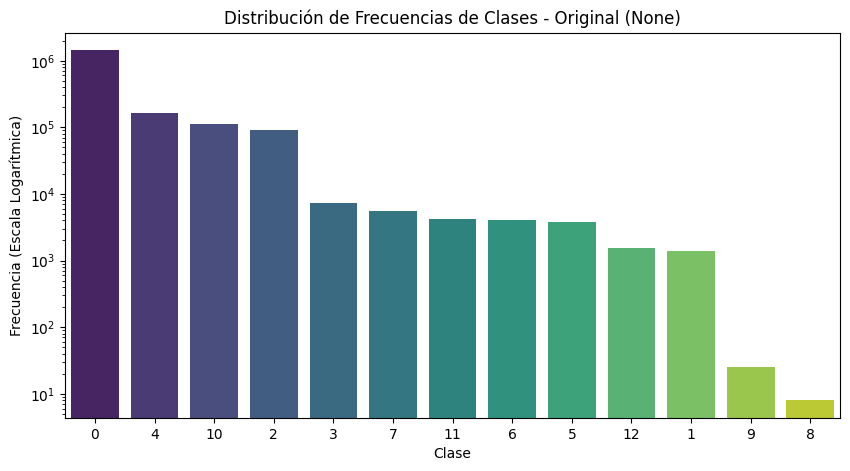

Analisis de Distribucion: SMOTE
Total de muestras: 2,283,133
Número de clases: 13
Imbalance Ratio: 44781.28:1

 Clase  Conteo Porcentaje (%)
     0 1433001       62.7647%
     4  200000        8.7599%
     2  200000        8.7599%
    10  200000        8.7599%
     7   50000        2.1900%
     3   50000        2.1900%
     6   30000        1.3140%
    11   30000        1.3140%
    12   30000        1.3140%
     5   30000        1.3140%
     1   30000        1.3140%
     9     100        0.0044%
     8      32        0.0014%


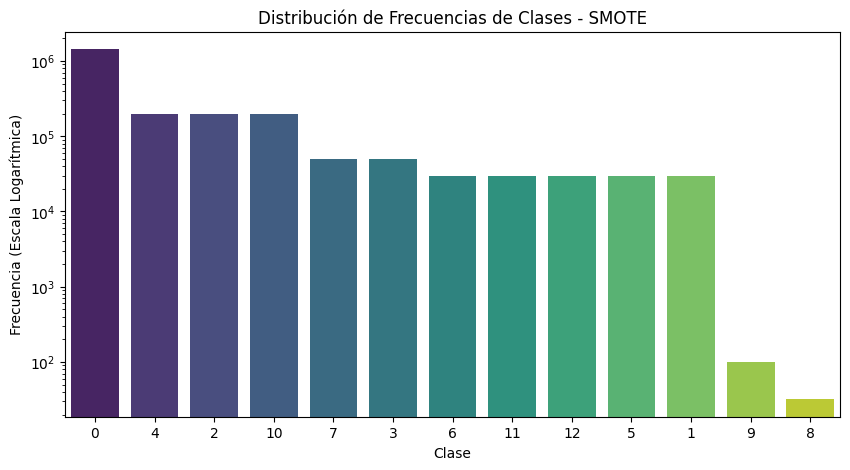

Analisis de Distribucion: SMOTE-ENN
Total de muestras: 2,268,391
Número de clases: 13
Imbalance Ratio: 44599.00:1

 Clase  Conteo Porcentaje (%)
     0 1427168       62.9154%
     2  199867        8.8110%
     4  198291        8.7415%
    10  198279        8.7410%
     7   49952        2.2021%
     3   49874        2.1987%
     6   29793        1.3134%
     5   29774        1.3126%
    12   29480        1.2996%
    11   28682        1.2644%
     1   27132        1.1961%
     9      67        0.0030%
     8      32        0.0014%


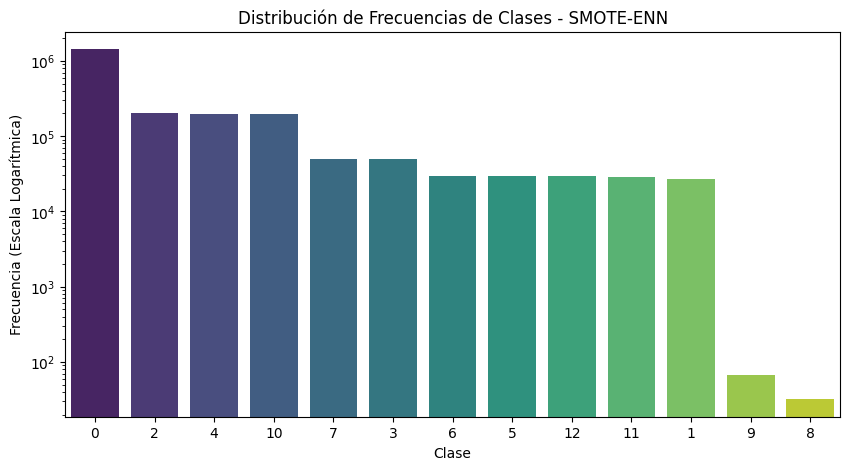

Analisis de Distribucion: SMOTE-TOMEK
Total de muestras: 2,280,895
Número de clases: 13
Imbalance Ratio: 44749.56:1

 Clase  Conteo Porcentaje (%)
     0 1431986       62.7818%
     2  199984        8.7678%
     4  199867        8.7627%
    10  199837        8.7613%
     7   49992        2.1918%
     3   49967        2.1907%
    11   29972        1.3140%
     6   29954        1.3133%
     5   29941        1.3127%
    12   29934        1.3124%
     1   29333        1.2860%
     9      96        0.0042%
     8      32        0.0014%


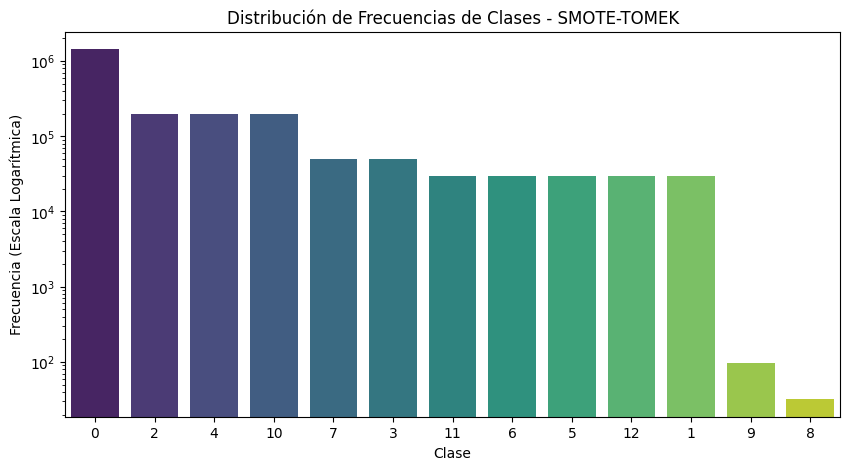

In [35]:
classes, counts = analizar_distribuciones(y_train_none_grouped, "Original (None)")
classes, counts = analizar_distribuciones(y_train_smote_grouped, "SMOTE")
classes, counts = analizar_distribuciones(y_train_smote_enn_grouped, "SMOTE-ENN")
classes, counts = analizar_distribuciones(y_train_smote_tomek_grouped, "SMOTE-TOMEK")

In [6]:
train_datasets_grouped = {
    'none': (X_train_none_grouped, y_train_none_grouped.values.ravel() if isinstance(y_train_none_grouped, pd.DataFrame) else y_train_none_grouped.ravel()),
    'smote': (X_train_smote_grouped, y_train_smote_grouped.values.ravel() if isinstance(y_train_smote_grouped, pd.DataFrame) else y_train_smote_grouped.ravel()),
    'smote_enn': (X_train_smote_enn_grouped, y_train_smote_enn_grouped.values.ravel() if isinstance(y_train_smote_enn_grouped, pd.DataFrame) else y_train_smote_enn_grouped.ravel()),
    'smote_tomek': (X_train_smote_tomek_grouped, y_train_smote_tomek_grouped.values.ravel() if isinstance(y_train_smote_tomek_grouped, pd.DataFrame) else y_train_smote_tomek_grouped.ravel())
}